In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/mlb_players_18.csv")

# Quick look
df.head()

,name,team,position,games,AB,R,H,doubles,triples,HR,RBI,walks,strike_outs,stolen_bases,caught_stealing_base,AVG,OBP,SLG,OPS
0,"Allard, K",ATL,P,3,1,1,1,0,0,0,0,0,0,0,0,1.0,1.0,1.0,2.0
1,"Gibson, K",MIN,P,1,2,2,2,0,0,0,0,0,0,0,0,1.0,1.0,1.0,2.0
2,"Law, D",SF,P,7,1,1,1,0,0,0,0,0,0,0,0,1.0,1.0,1.0,2.0
3,"Nuno, V",TB,P,1,2,0,2,0,0,0,1,0,0,0,0,1.0,1.0,1.0,2.0
4,"Romero, E",KC,P,4,1,1,1,1,0,0,0,0,0,0,0,1.0,1.0,2.0,3.0


In [2]:
# SEt seaborn style
sns.set(style="whitegrid", context="talk", palette="muted")

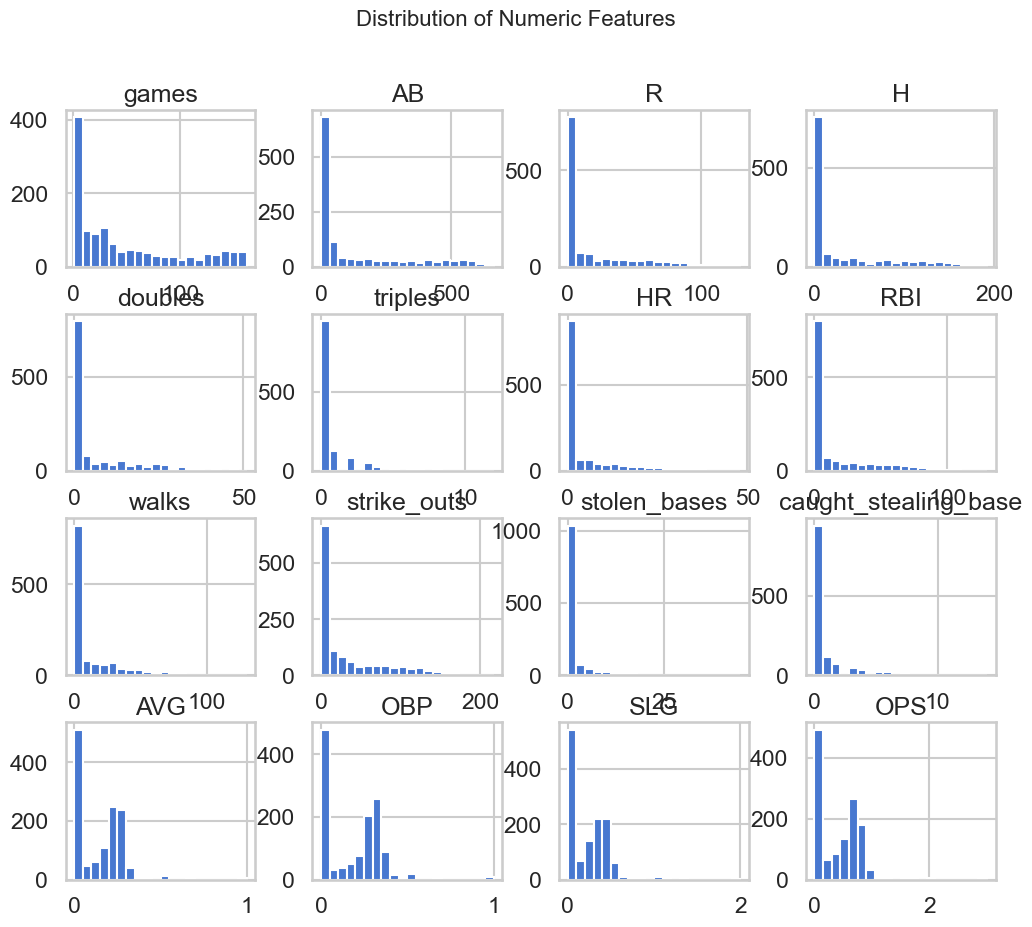

In [3]:
# Numerical Feature Distribution
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(bins=20, figsize=(12, 10))
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

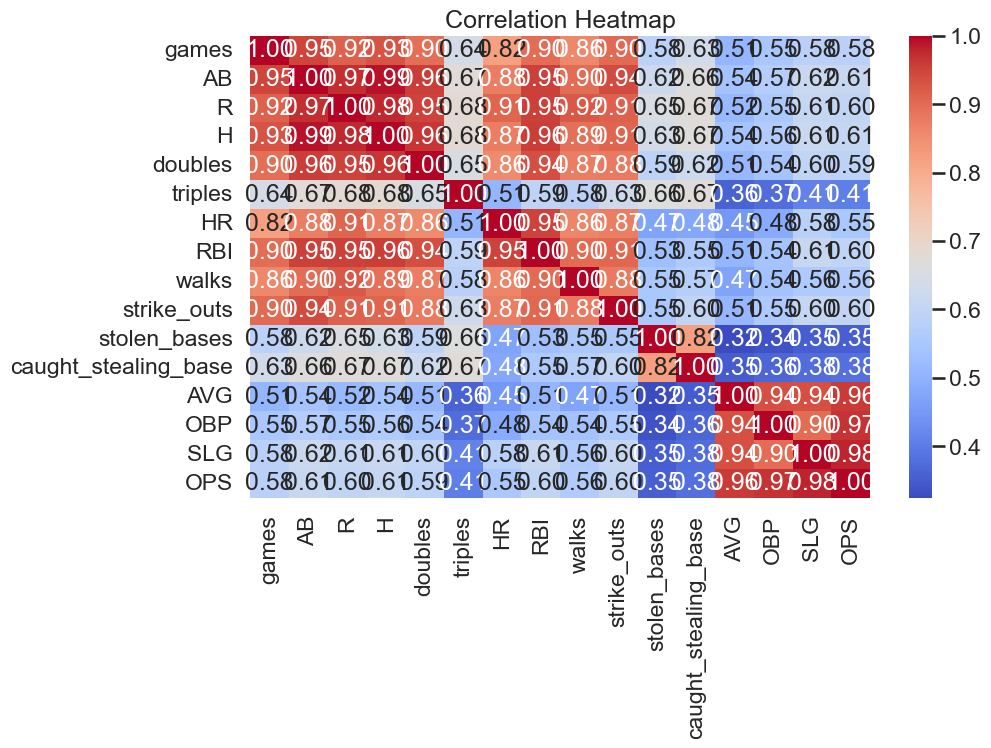

In [4]:
# Correlation Heatmap - reveal relationships between stats (e.g. hits <-> batting avg)

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

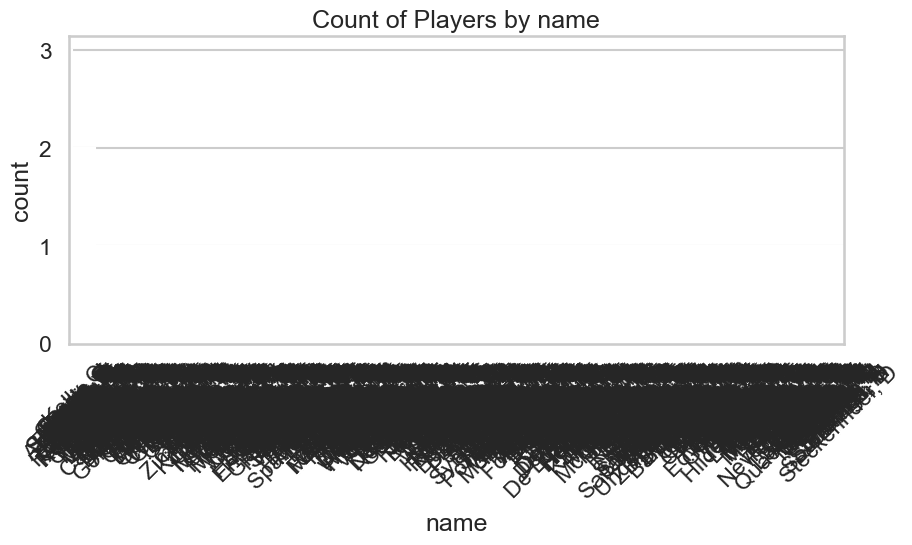

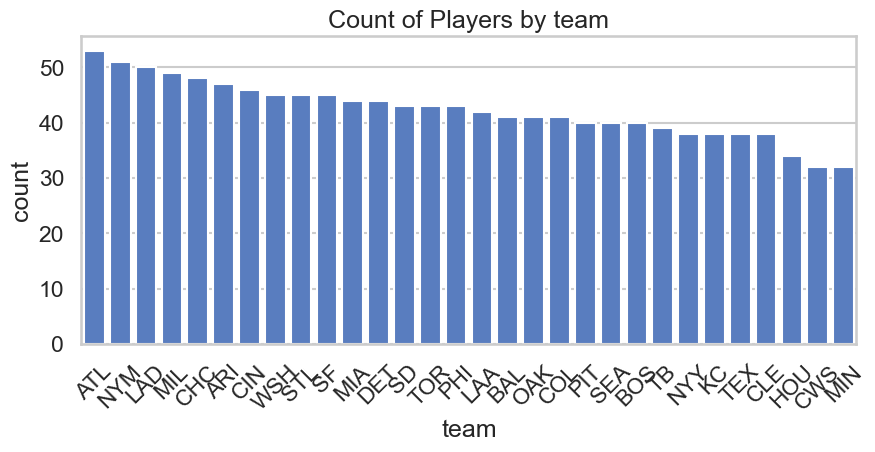

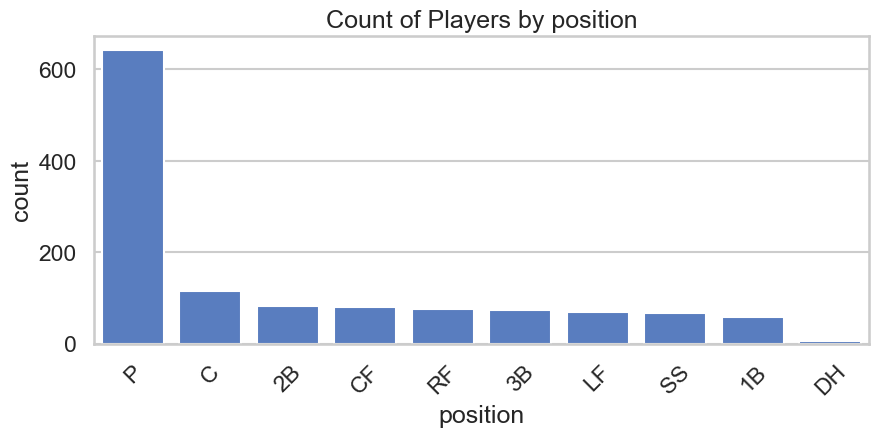

In [5]:
# Category counts
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count of Players by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [6]:
# Relationship with Salary if present
if 'salary' in df.columns:
    sns.pairplot(df, vars=numeric_cols, y_vars=['salary'], corner=True)
    plt.suptitle("Relationships Between Stats and Salary", y=1.02)
    plt.show()

In [7]:
# Save Clean Version
df.to_csv("../data/mlb_players_clean.csv", index=False)

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Load your cleanded dataset
df = pd.read_csv("../data/mlb_players_clean.csv")
df.head()
df.columns

Index(['name', 'team', 'position', 'games', 'AB', 'R', 'H', 'doubles',
       'triples', 'HR', 'RBI', 'walks', 'strike_outs', 'stolen_bases',
       'caught_stealing_base', 'AVG', 'OBP', 'SLG', 'OPS'],
      dtype='object')

In [14]:
# Target Variable - what we want to predict
y = df["OBP"]

# Feature Variables - drop non numeric identifiers
X = df.drop(columns=["OBP", "name", "team"])

In [15]:
# Step 3 - Identify Colum Types
numeric_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numeric: ['games', 'AB', 'R', 'H', 'doubles', 'triples', 'HR', 'RBI', 'walks', 'strike_outs', 'stolen_bases', 'caught_stealing_base', 'AVG', 'SLG', 'OPS']
Categorical: ['position']


In [19]:
# Step 4 — Preprocessing Pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

In [20]:
# Step 5 — Combine Preprocessor + Model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [21]:
# Step 6 — Train/Test Split and Fit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
# Step 7 — Evaluate Performance
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.00015130587404558018
R²: 0.9999942182337894


In [23]:
# Step 8 — Save the Model
joblib.dump(model, "../models/mlb_salary_model.joblib")

['../models/mlb_salary_model.joblib']

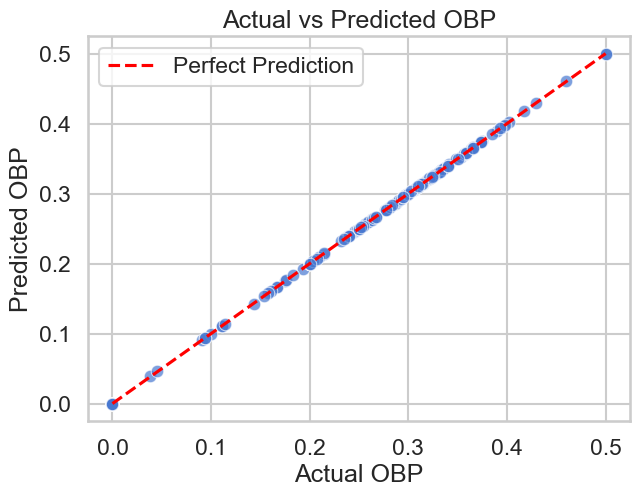

In [25]:
# Sanity Check: Actual vs Predicted OBP
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions for test set
y_pred = model.predict(X_test)

# Combine into a DataFrame for easier plotting
results = pd.DataFrame({"Actual_OBP": y_test, "Predicted_OBP": y_pred})

# Scatter plot
plt.figure(figsize=(7, 5))
sns.scatterplot(data=results, x="Actual_OBP", y="Predicted_OBP", alpha=0.7)
plt.plot([results.min().min(), results.max().max()],
         [results.min().min(), results.max().max()],
         color='red', linestyle='--', label="Perfect Prediction")
plt.title("Actual vs Predicted OBP")
plt.xlabel("Actual OBP")
plt.ylabel("Predicted OBP")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Diagnostic Metrics Table - Delete and retype later.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Compute metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display neatly
metrics_table = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [mae, rmse, r2]
})

print("\nModel Performance Metrics:")
display(metrics_table)



Model Performance Metrics:


,Metric,Value
0,Mean Absolute Error (MAE),0.000151
1,Root Mean Squared Error (RMSE),0.000362
2,R² Score,0.999994


In [8]:
# Inspect Dataset

# Basic Info
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1270 entries, 0 to 1269
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  1270 non-null   object 
 1   team                  1270 non-null   object 
 2   position              1270 non-null   object 
 3   games                 1270 non-null   int64  
 4   AB                    1270 non-null   int64  
 5   R                     1270 non-null   int64  
 6   H                     1270 non-null   int64  
 7   doubles               1270 non-null   int64  
 8   triples               1270 non-null   int64  
 9   HR                    1270 non-null   int64  
 10  RBI                   1270 non-null   int64  
 11  walks                 1270 non-null   int64  
 12  strike_outs           1270 non-null   int64  
 13  stolen_bases          1270 non-null   int64  
 14  caught_stealing_base  1270 non-null   int64  
 15  AVG                  

In [11]:
# Numeric Summary
df.describe()

,games,AB,R,H,doubles,triples,HR,RBI,walks,strike_outs,stolen_bases,caught_stealing_base,AVG,OBP,SLG,OPS
count,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000,1270.000000
mean,48.171654,130.261417,17.031496,32.297638,6.507087,0.666929,4.397638,16.225197,12.351181,32.446457,1.948031,0.754331,0.140191,0.181824,0.217412,0.399239
std,49.957749,185.855484,26.896304,49.396815,10.487391,1.517461,8.036863,26.085535,20.680606,44.687302,5.018058,1.769933,0.140268,0.165976,0.218611,0.374984
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,23.500000,1.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,8.000000,0.000000,0.000000,0.166000,0.217500,0.214000,0.436500
75%,79.750000,213.750000,27.000000,50.000000,10.000000,1.000000,5.000000,24.000000,18.000000,54.000000,1.000000,1.000000,0.247000,0.316000,0.395000,0.703000
max,162.000000,664.000000,129.000000,192.000000,51.000000,12.000000,48.000000,130.000000,130.000000,217.000000,45.000000,14.000000,1.000000,1.000000,2.000000,3.000000


In [12]:
# Missing values
df.isnull().sum().sort_values(ascending=False)

name                    0
team                    0
position                0
games                   0
AB                      0
R                       0
H                       0
doubles                 0
triples                 0
HR                      0
RBI                     0
walks                   0
strike_outs             0
stolen_bases            0
caught_stealing_base    0
AVG                     0
OBP                     0
SLG                     0
OPS                     0
dtype: int64

In [10]:
# confirm column types
df.dtypes

name                     object
team                     object
position                 object
games                     int64
AB                        int64
R                         int64
H                         int64
doubles                   int64
triples                   int64
HR                        int64
RBI                       int64
walks                     int64
strike_outs               int64
stolen_bases              int64
caught_stealing_base      int64
AVG                     float64
OBP                     float64
SLG                     float64
OPS                     float64
dtype: object

In [14]:
df.duplicated().sum()

np.int64(0)